# GFDL-ESM4 full-depth sampling-sensitivity maps

Generate separate 3×2 figures for Ito (2022) and Ito (2024) RF. Each figure shows the fully sampled GFDL-ESM4 trend and the five sampling-sensitivity experiments.

In [1]:
from pathlib import Path
import string

import netCDF4 as nc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from cartopy import crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point


PAPER = Path("/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures")
WORK = Path("/scratch/gpfs/LRGROUP/db9274/GFDL_ESM4_artificial_subsampling")
TREND_DIR = WORK / "trend_comparison_outputs/fully_minus_gap_filled_trend_maps"
FULL = PAPER / "NETCDF/Fully_sampled_models_annual_o2/o2_1x1bin_GFDL_ESM4_r1i1p1f1.nc"
OI_SHIP = TREND_DIR / "ito2022_original_4x_4xeast_8x.nc"
RF_SHIP = TREND_DIR / "ito2024_rf_original_4x_4xeast_8x.nc"
OI_IDEALIZED = Path('Figures/GFDL_ESM4_oi_idealized_sampling_full_depth_1967_2019.nc')
RF_IDEALIZED = Path('Figures/GFDL_ESM4_rf_idealized_sampling_full_depth_1965_2021.nc')

OI_OUTPUT = Path("Figures/GFDL_ESM4_Ito2022_sampling_sensitivity_full_depth_maps.pdf")
RF_OUTPUT = Path("Figures/GFDL_ESM4_Ito2024_RF_sampling_sensitivity_full_depth_maps.pdf")

METHODS = [
    ("Ito (2022)", 1967, 2019),
    ("Ito (2024): RF", 1965, 2021),
]
ROWS = [
    "Historical sampling",
    "Uniform sampling\n(at historical coverage)",
    "Uniform sampling\n(30% coverage)",
    "Historical sampling +\n2,000 profiles in\nTropical Oceans",
    "Historical sampling +\n2,000 profiles in\nNorth Atlantic + North\nPacific Oceans",
    "Historical sampling +\n2,000 profiles in\nSouthern Ocean",
]

In [2]:
def layer_edges(lev):
    lev = np.asarray(lev, dtype=float)
    edges = np.empty(lev.size + 1)
    edges[1:-1] = 0.5 * (lev[:-1] + lev[1:])
    edges[0] = max(0.0, lev[0] - 0.5 * (lev[1] - lev[0]))
    edges[-1] = lev[-1] + 0.5 * (lev[-1] - lev[-2])
    return edges


def read_years(ds):
    return np.array(
        [
            date.year
            for date in nc.num2date(
                ds.variables["time"][:],
                ds.variables["time"].units,
                calendar=getattr(ds.variables["time"], "calendar", "standard"),
            )
        ],
        dtype=int,
    )


def calculate_level_trend(path, start, end):
    """Calculate a per-level linear trend while streaming one year at a time."""
    wanted = np.arange(start, end + 1)
    with nc.Dataset(path) as ds:
        years = read_years(ds)
        zname = "lev" if "lev" in ds.variables else "depth"
        yname = "y" if "y" in ds.variables else "lat"
        xname = "x" if "x" in ds.variables else "lon"
        lev = np.asarray(ds.variables[zname][:], dtype=float)
        lat = np.asarray(ds.variables[yname][:], dtype=float)
        lon = np.mod(np.asarray(ds.variables[xname][:], dtype=float), 360)
        var = ds.variables["o2"]
        time_axis = var.dimensions.index("time")
        remaining = [dim for dim in var.dimensions if dim != "time"]
        order = [remaining.index(dim) for dim in (zname, yname, xname)]
        shape = (lev.size, lat.size, lon.size)
        sums = {name: np.zeros(shape, dtype=float) for name in ("n", "sx", "sy", "sxx", "sxy")}

        for year in wanted:
            total = np.zeros(shape, dtype=float)
            count = np.zeros(shape, dtype=np.uint8)
            for ti in np.flatnonzero(years == year):
                index = [slice(None)] * var.ndim
                index[time_axis] = int(ti)
                values = np.ma.filled(var[tuple(index)], np.nan).astype(float)
                values[values > 1e19] = np.nan
                values = np.transpose(values, order)
                valid = np.isfinite(values)
                total += np.where(valid, values, 0)
                count += valid
            annual = np.divide(total, count, out=np.full(shape, np.nan), where=count > 0)
            valid = np.isfinite(annual)
            sums["n"] += valid
            sums["sx"] += np.where(valid, year, 0)
            sums["sy"] += np.where(valid, annual, 0)
            sums["sxx"] += np.where(valid, year * year, 0)
            sums["sxy"] += np.where(valid, year * annual, 0)

    denominator = sums["n"] * sums["sxx"] - sums["sx"] ** 2
    trend = np.divide(
        sums["n"] * sums["sxy"] - sums["sx"] * sums["sy"],
        denominator,
        out=np.full(shape, np.nan),
        where=(sums["n"] == wanted.size) & (denominator != 0),
    ) * 10
    return lev, lat, lon, trend


def full_depth_mean(level_field, lev):
    thickness = np.diff(layer_edges(lev))[:, None, None]
    valid = np.isfinite(level_field)
    numerator = np.nansum(np.where(valid, level_field * thickness, np.nan), axis=0)
    denominator = np.sum(np.where(valid, thickness, 0), axis=0)
    return np.divide(
        numerator,
        denominator,
        out=np.full(numerator.shape, np.nan),
        where=denominator > 0,
    )


def full_depth_from_bands(ds, prefix, upper_volume, lower_volume):
    upper = np.asarray(ds[f"{prefix}_upper_2000m"], dtype=float)
    lower = np.asarray(ds[f"{prefix}_below_2000m"], dtype=float)
    upper_valid = np.isfinite(upper) & (upper_volume > 0)
    lower_valid = np.isfinite(lower) & (lower_volume > 0)
    numerator = np.where(upper_valid, upper * upper_volume, 0) + np.where(
        lower_valid, lower * lower_volume, 0
    )
    denominator = np.where(upper_valid, upper_volume, 0) + np.where(
        lower_valid, lower_volume, 0
    )
    return np.divide(
        numerator,
        denominator,
        out=np.full(numerator.shape, np.nan),
        where=denominator > 0,
    )


def ocean_band_volumes():
    with nc.Dataset(FULL) as ds:
        lev = np.asarray(ds.variables["lev"][:], dtype=float)
        var = ds.variables["o2"]
        time_axis = var.dimensions.index("time")
        index = [slice(None)] * var.ndim
        index[time_axis] = 0
        snapshot = np.ma.filled(var[tuple(index)], np.nan)
        remaining = [dim for dim in var.dimensions if dim != "time"]
        snapshot = np.transpose(
            snapshot,
            [remaining.index("lev"), remaining.index("y"), remaining.index("x")],
        )
    edges = layer_edges(lev)
    thickness = np.diff(edges)
    upper_thickness = np.maximum(np.minimum(edges[1:], 2000) - edges[:-1], 0)
    lower_thickness = np.maximum(edges[1:] - np.maximum(edges[:-1], 2000), 0)
    valid = np.isfinite(snapshot)
    upper = np.sum(np.where(valid, upper_thickness[:, None, None], 0), axis=0)
    lower = np.sum(np.where(valid, lower_thickness[:, None, None], 0), axis=0)
    return upper, lower

In [3]:
def load_maps():
    upper_volume, lower_volume = ocean_band_volumes()
    with xr.open_dataset(OI_SHIP) as oi_ship, xr.open_dataset(RF_SHIP) as rf_ship, \
            xr.open_dataset(OI_IDEALIZED) as oi_idealized, \
            xr.open_dataset(RF_IDEALIZED) as rf_idealized:
        lat = oi_ship.lat.values
        lon = oi_ship.lon.values
        expected = ['uniform_historical_coverage', 'uniform_30_percent',
                    'added_tropical_2000', 'added_north_atlantic_pacific_2000',
                    'added_southern_ocean_2000']
        for cache in (oi_idealized, rf_idealized):
            if cache.experiment.values.tolist() != expected:
                raise ValueError('Unexpected sampling experiments in full-depth cache')
            if not (np.allclose(cache.lat, lat) and np.allclose(cache.lon, lon)):
                raise ValueError('Full-depth cache grid differs from original map')
        # Original maps store fully sampled minus mapped; idealized caches already store mapped minus full.
        oi_maps = [
            -full_depth_from_bands(oi_ship, "fully_minus_gap_filled_original", upper_volume, lower_volume),
            *[oi_idealized.mapped_minus_full.sel(experiment=name).values for name in expected],
        ]
        rf_maps = [
            -full_depth_from_bands(rf_ship, "fully_minus_gap_filled_original", upper_volume, lower_volume),
            *[rf_idealized.mapped_minus_full.sel(experiment=name).values for name in expected],
        ]

    return lat, lon, [oi_maps, rf_maps]

  o2_grid_1x1_GFDL_ESM4_regional_tropical_2000.nc: longitudes 1-90


  o2_grid_1x1_GFDL_ESM4_regional_tropical_2000.nc: longitudes 91-180


  o2_grid_1x1_GFDL_ESM4_regional_tropical_2000.nc: longitudes 181-270


  o2_grid_1x1_GFDL_ESM4_regional_tropical_2000.nc: longitudes 271-360


  o2_grid_1x1_GFDL_ESM4_regional_extratropical_2000.nc: longitudes 1-90


...

  o2_grid_1x1_GFDL_ESM4_regional_extratropical_2000.nc: longitudes 271-360


  o2_grid_1x1_GFDL_ESM4_regional_southern_ocean_2000.nc: longitudes 1-90


  o2_grid_1x1_GFDL_ESM4_regional_southern_ocean_2000.nc: longitudes 91-180


  o2_grid_1x1_GFDL_ESM4_regional_southern_ocean_2000.nc: longitudes 181-270


  o2_grid_1x1_GFDL_ESM4_regional_southern_ocean_2000.nc: longitudes 271-360


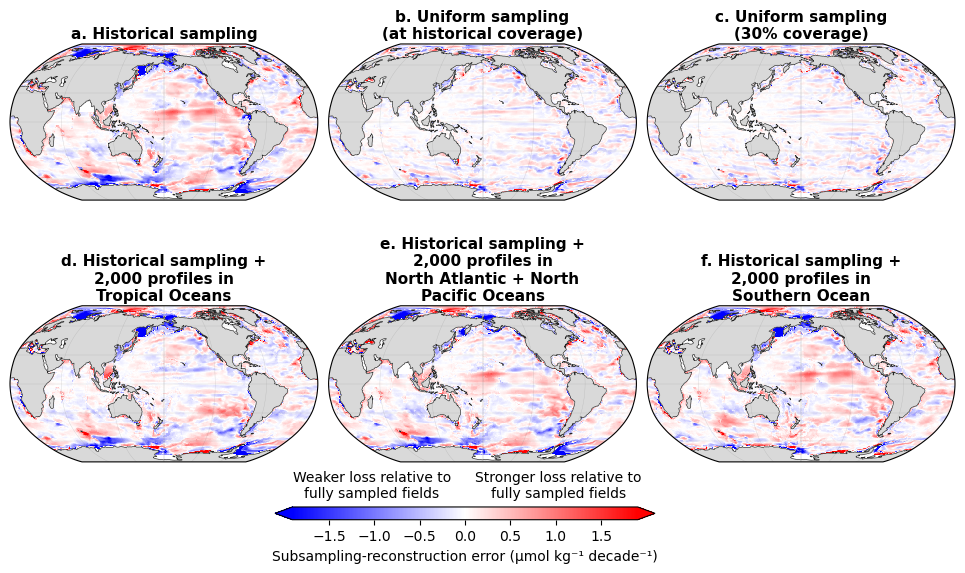

Saved Figures/GFDL_ESM4_Ito2022_sampling_sensitivity_full_depth_maps.pdf


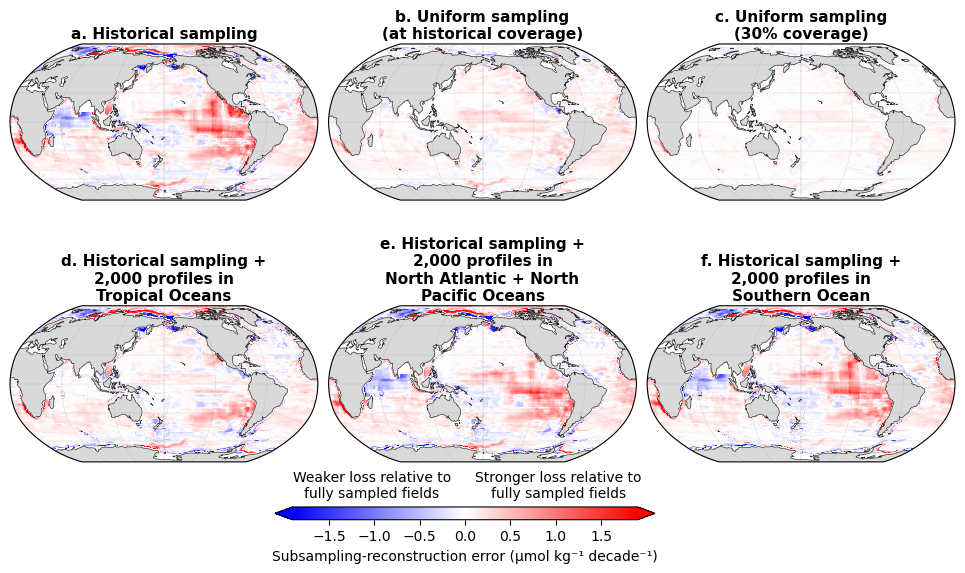

Saved Figures/GFDL_ESM4_Ito2024_RF_sampling_sensitivity_full_depth_maps.pdf


In [4]:
def make_figure(lat, lon, fields, method, norm, output):
    projection = ccrs.Robinson(central_longitude=180)
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(10, 5.8),
        subplot_kw={"projection": projection},
        gridspec_kw={"left": 0.045, "right": 0.99, "top": 0.88, "bottom": 0.15, "wspace": 0.035, "hspace": 0.62},
    )

    mesh = None
    for index, field in enumerate(fields):
        plot_row, col = divmod(index, 3)
        ax = axes[plot_row, col]
        if field is not None:
            cyclic, cyclic_lon = add_cyclic_point(field, coord=lon)
            mesh = ax.pcolormesh(
                cyclic_lon,
                lat,
                cyclic,
                transform=ccrs.PlateCarree(),
                cmap="bwr",
                norm=norm,
                shading="auto",
                rasterized=True,
            )
        ax.set_global()
        ax.add_feature(cfeature.LAND, facecolor="0.85", edgecolor="none", zorder=2)
        ax.coastlines(linewidth=0.45, color="0.15", zorder=3)
        ax.gridlines(linewidth=0.25, color="0.55", alpha=0.4)
        if field is None:
            ax.text(
                0.5,
                0.5,
                "Global RF output\nnot available",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=8,
                color="0.25",
                zorder=4,
            )
        ax.set_title(f"{string.ascii_lowercase[index]}. {ROWS[index]}", fontsize=11, fontweight="bold", pad=4)


    cbar_ax = fig.add_axes([0.31, 0.055, 0.38, 0.022])
    cbar = fig.colorbar(mesh, cax=cbar_ax, orientation="horizontal", extend="both")
    cbar.set_label(
        "Subsampling-reconstruction error (µmol kg⁻¹ decade⁻¹)", fontsize=10
    )
    cbar.ax.tick_params(labelsize=10)
    cbar_ax.text(0.23, 1.55, 'Weaker loss relative to\nfully sampled fields',
                 transform=cbar_ax.transAxes, ha='center', va='bottom', fontsize=10)
    cbar_ax.text(0.77, 1.55, 'Stronger loss relative to\nfully sampled fields',
                 transform=cbar_ax.transAxes, ha='center', va='bottom', fontsize=10)

    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output, bbox_inches="tight", pad_inches=0.03)
    plt.show()
    print(f"Saved {output}")


def main():
    lat, lon, columns = load_maps()
    available = [field for column in columns for field in column if field is not None]
    limit = float(
        np.nanpercentile(
            np.concatenate([np.abs(field[np.isfinite(field)]) for field in available]),
            99,
        )
    )
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    plt.rcParams.update(
        {
            "font.size": 8,
            "axes.titlesize": 9,
            "pdf.fonttype": 42,
            "savefig.dpi": 600,
            "savefig.facecolor": "white",
        }
    )
    make_figure(lat, lon, columns[0], METHODS[0], norm, OI_OUTPUT)
    make_figure(lat, lon, columns[1], METHODS[1], norm, RF_OUTPUT)


if __name__ == "__main__":
    main()

**GFDL_ESM4_Ito2022_sampling_sensitivity_full_depth_maps.pdf**

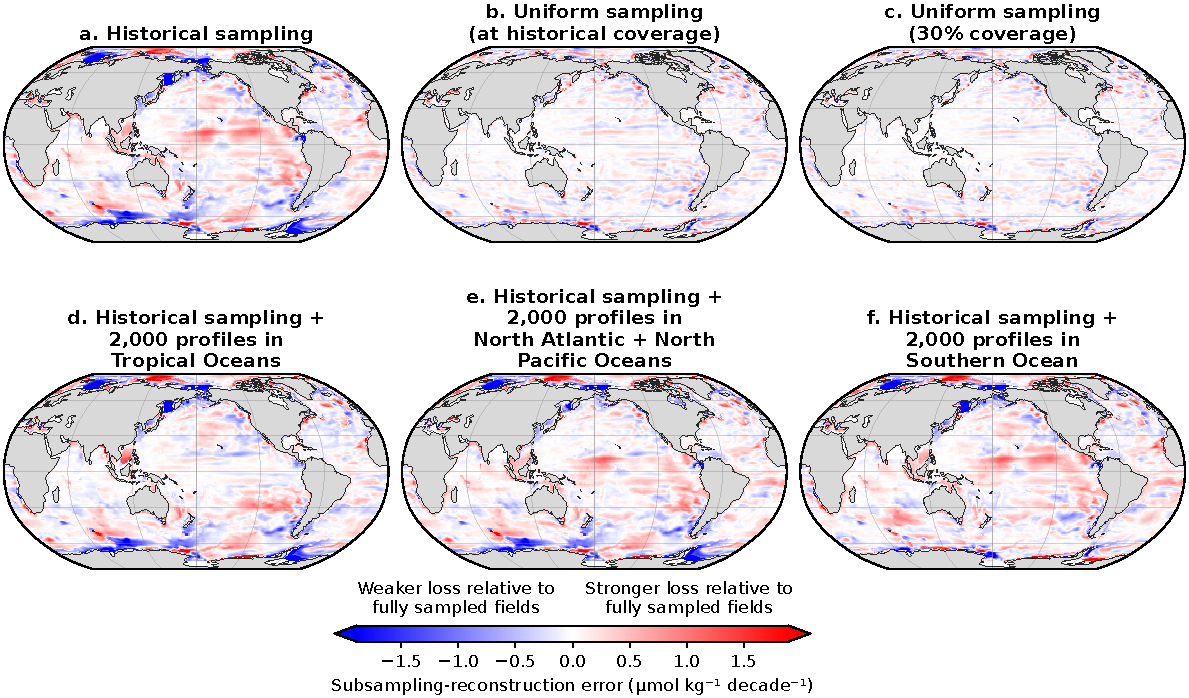

**GFDL_ESM4_Ito2024_RF_sampling_sensitivity_full_depth_maps.pdf**

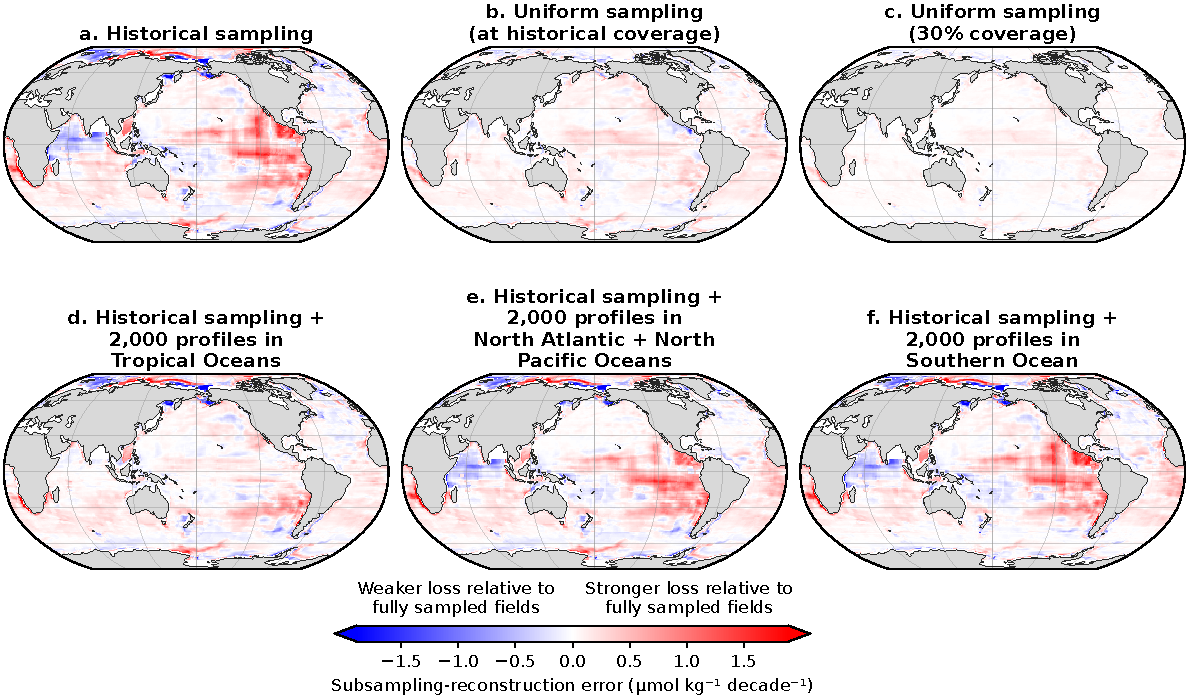

In [5]:
# Show the saved paper PDF in GitHub's notebook viewer.
from pathlib import Path
from tempfile import TemporaryDirectory
from IPython.display import Image, Markdown, display
import subprocess

PDF_PREVIEWS = tuple(Path(name) for name in ['Figures/GFDL_ESM4_Ito2022_sampling_sensitivity_full_depth_maps.pdf', 'Figures/GFDL_ESM4_Ito2024_RF_sampling_sensitivity_full_depth_maps.pdf'])

for pdf in PDF_PREVIEWS:
    display(Markdown(f"**{pdf.name}**"))
    with TemporaryDirectory() as temporary_dir:
        preview = Path(temporary_dir) / "preview.png"
        subprocess.run(["gs", "-q", "-dSAFER", "-dBATCH", "-dNOPAUSE",
                        "-sDEVICE=png16m", "-r125", "-dFirstPage=1", "-dLastPage=1",
                        f"-sOutputFile={preview}", str(pdf)], check=True)
        display(Image(filename=str(preview)))
